<a href="https://colab.research.google.com/github/Husnul66/Pratech-TimeSeries-Forecasting/blob/main/Stokanalizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Değerlendirme Ekibinin Dikkatine (Veri Seti Kurulumu)

# Bu projenin (Notebook) hatasız çalışabilmesi için Kaggle'daki "Store Item Demand Forecasting Challenge" yarışmasına ait train.csv dosyasının bu dosya ile aynı dizinde (klasörde) bulunması gerekmektedir.

# Veri Seti Linki: https://www.kaggle.com/c/demand-forecasting-kernels-only/data

# Eğer projeyi Google Colab üzerinde inceliyorsanız: Lütfen train.csv dosyasını sol taraftaki "Dosyalar" (Files) paneline sürükleyip bıraktıktan sonra hücreleri çalıştırınız.

# Eğer yerel (Local) Jupyter ortamında inceliyorsanız: train.csv dosyasını bu .ipynb dosyası ile aynı klasöre koymanız yeterlidir. Kod içindeki pd.read_csv('train.csv') komutu veriyi otomatik okuyacaktır.

In [ ]:
# kutuphaneler tanimi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose



In [ ]:
                                                  # Veri Temizleme ve Tanıma asamasi

url = 'https://raw.githubusercontent.com/Husnul66/Pratech-TimeSeries-Forecasting/refs/heads/main/train.csv'
df = pd.read_csv(url)

# df = pd.read_csv('train.csv')   # csv dosyamizi okuyup df degiskeni icerisine atiyoruz (Su an dosyamiz drik linkini koyedugum githubtan okunyor, o yuzden burayi yorum strina aldim , eger manual celistirilmek istenirse bu satri yorum satrinden cikarilmeli)


df['date'] = pd.to_datetime(df['date'])   # Tarih sütununu string'den datetime formatına çevirme


print("--- Veri Seti genel Bilgisi ---")   # Verinin genel yapısı
df.info()

print("\n--- Eksik Veri (NaN) larin toplami ---")   # bos stunlarin toplami
print(df.isnull().sum())

# İlk 5 satırı görüntüleme
df.head()

--- Veri Seti genel Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB

--- Eksik Veri (NaN) larin toplami ---
date     0
store    0
item     0
sales    0
dtype: int64


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
df.describe()    # verinin daha detayli seklinde inceler

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [ ]:
# Tekrarlayan satır sayısını bulma
duplicate_count = df.duplicated().sum()
print(f"Tekrarlayan satır sayısı: {duplicate_count}")

# Eğer varsa, tekrarlayan satırları silme (İlk kaydı tutar, diğerlerini atar)
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first')
    print("Tekrarlayan satırlar temizlendi.")

Tekrarlayan satır sayısı: 0


In [ ]:
# Hangi sütunda kaç tane eksik veri var?

missing_values = df.isnull().sum()
print("Eksik Veri Sayıları:\n", missing_values[missing_values > 0])

                          # Eksik verileri yönetme stratejileri :

# Strateji A: Eksik veri sayısı çok azsa , o satırları direkt silebiliriz.
# df = df.dropna()

# Strateji B: Sayısal değişkenlerde eksik yerleri "Ortalama" veya "Medyan" ile doldurma.
# df['fiyat'] = df['fiyat'].fillna(df['fiyat'].median())


Eksik Veri Sayıları:
 Series([], dtype: int64)


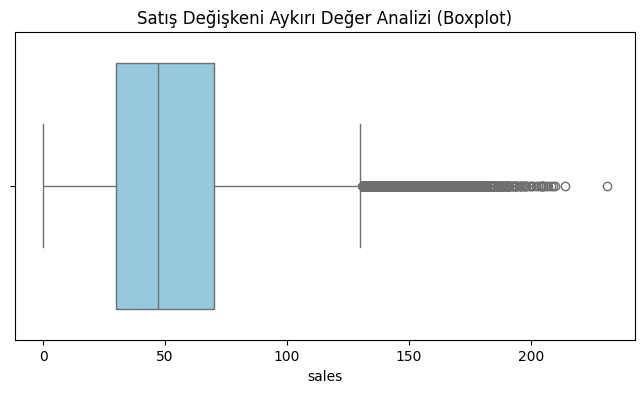

In [ ]:
# İstenen sayısal sütun için aykırı değerleri görselleştirme
# örenk  her hangi sutuna 10 yerine 10000 girilirse bu graf ile daha kolay sayısal değeri ayıklayabiliriz

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['sales'], color='skyblue')
plt.title("Satış Değişkeni Aykırı Değer Analizi (Boxplot)")
plt.show()

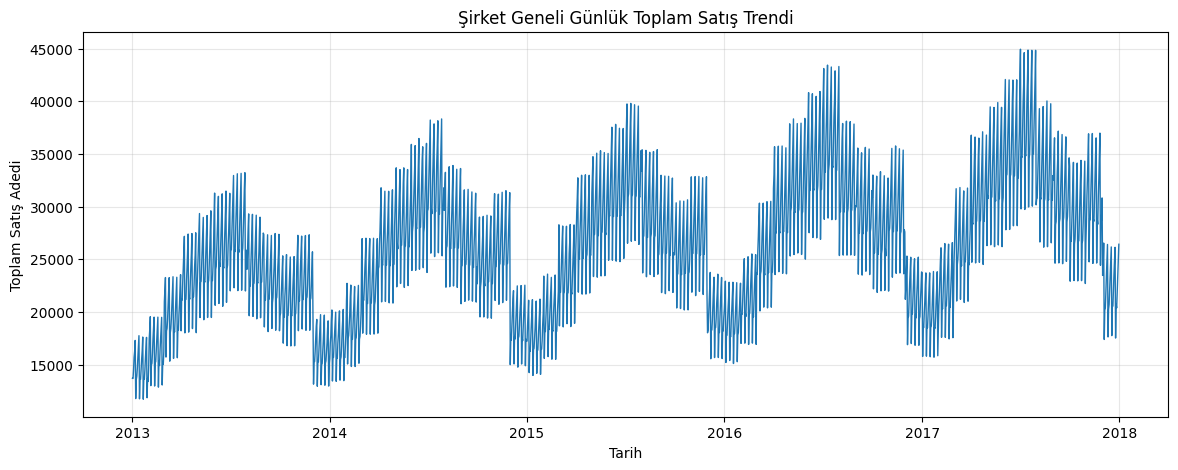

In [ ]:
                                                #Şirket Geneli Günlük Toplam Satış Trendi


# 913 bin satır bu çok büyüktür. Trendi anlamak için tüm mağaza ve ürünlerin  günlük toplam satışlarını (şirket geneli) gruplayarak inceleriz.

daily_sales = df.groupby('date')['sales'].sum().reset_index()

# Genel satış trendini görselleştirelim
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_sales, x='date', y='sales', linewidth=1)
plt.title("Şirket Geneli Günlük Toplam Satış Trendi")
plt.xlabel("Tarih")
plt.ylabel("Toplam Satış Adedi")
plt.grid(alpha=0.3)
plt.show()

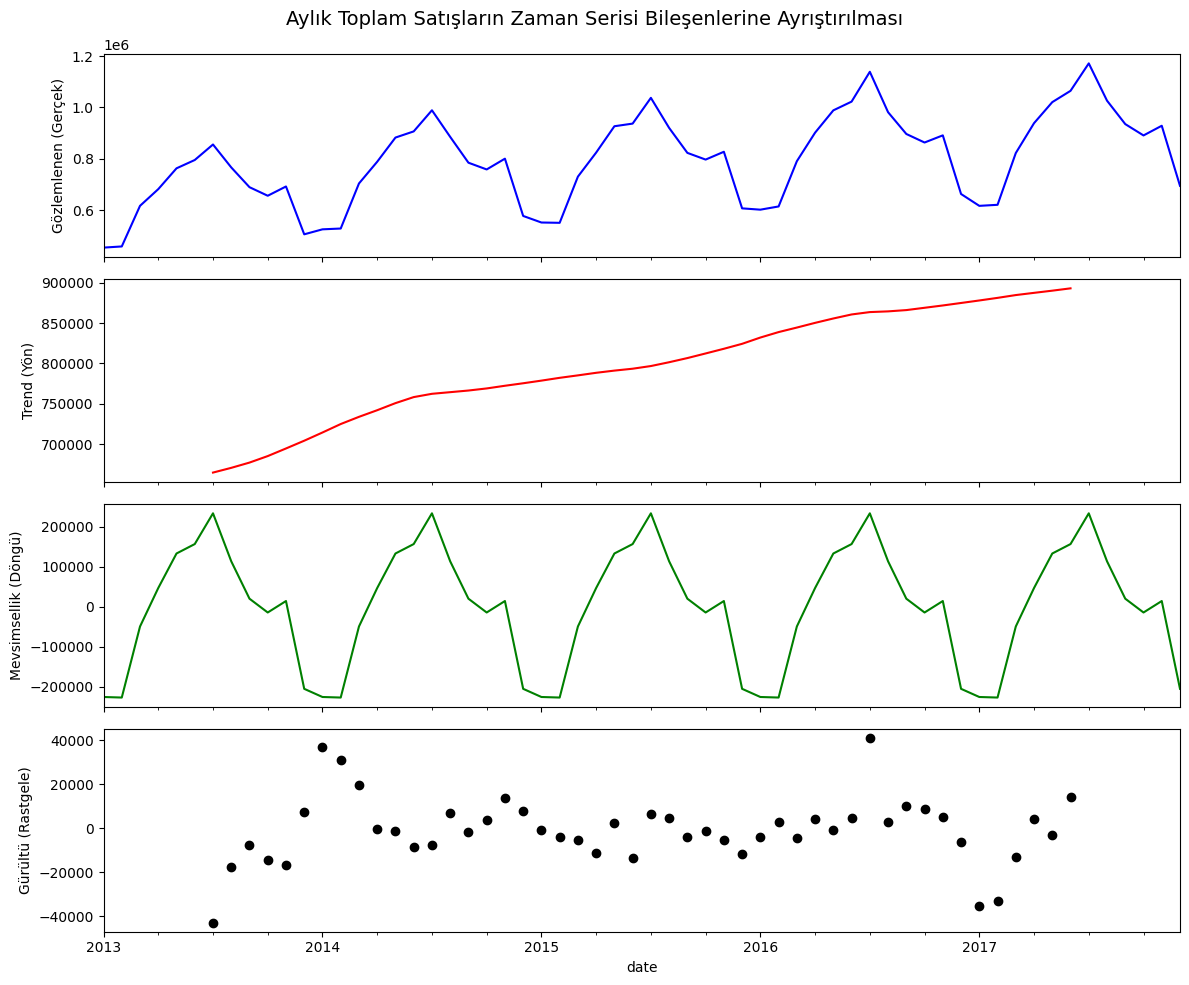

In [ ]:


# İşlemi hızlandırmak ve grafiği netleştirmek için günlük veriyi "Aylık" toplama çevirelim (Resampling)

monthly_sales = df.set_index('date').resample('ME')['sales'].sum()

# Zaman serisini bileşenlerine ayırma
decomposition = seasonal_decompose(monthly_sales, model='additive')

# Çizim ayarları
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=ax1, color='blue')
ax1.set_ylabel('Gözlemlenen (Gerçek)')

decomposition.trend.plot(ax=ax2, color='red')
ax2.set_ylabel('Trend (Yön)')

decomposition.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Mevsimsellik (Döngü)')

decomposition.resid.plot(ax=ax4, color='black', marker='o', linestyle='None')
ax4.set_ylabel('Gürültü (Rastgele)')

plt.suptitle("Aylık Toplam Satışların Zaman Serisi Bileşenlerine Ayrıştırılması", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
                                                 # ----  Özellık Mühendisliliği VE VERİ BÖLME  ----

# Tarihi modelin anlayacağı parçalara bölme


df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek


# Hafta sonu mu değil mi? (Satışları çok etkiler) -> Cumartesi(5) ve Pazar(6) ise 1, değilse 0
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)

#  Zamana Dayalı Veri Bölme

# Bu veri seti 2013 ile 2017 sonu arasındaki 5 yılı kapsıyor.
# İlk 4 yılı (2013-2016) modelin öğrenmesi (Train), ve son 1 yılı (2017) ise kendini test etmesi (Test) için ayırıyoruz.

train = df[df['date'] < '2017-01-01']
test = df[df['date'] >= '2017-01-01']

# 3. Modelin Girdilerini (X) ve Çıktısını (y) Belirleme
# 'date' sütununu çıkarıyoruz çünkü algoritmalar sadece sayısal verilerle çalışır.
features = ['store', 'item', 'year', 'month', 'day', 'dayofweek', 'is_weekend']
target = 'sales'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(" Özellik Mühendisliği ve Veri Bölme İşlemi Tamamlandı!\n")
print(f"Eğitim Seti (Train) Boyutu: {X_train.shape[0]} satır (Modelin geçmişi öğreneceği kısım)")
print(f"Test Seti (Test) Boyutu: {X_test.shape[0]} satır (Modelin geleceği tahmin edeceği kısım)")

 Özellik Mühendisliği ve Veri Bölme İşlemi Tamamlandı!

Eğitim Seti (Train) Boyutu: 730500 satır (Modelin geçmişi öğreneceği kısım)
Test Seti (Test) Boyutu: 182500 satır (Modelin geleceği tahmin edeceği kısım)


In [ ]:

# XGBoost Modelini Tanımlama

# (Parametreler: 1000 ağaç, öğrenme oranı 0.05. Bunlar iyi ve standart hiperparametrelerdir)

model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)

# Modeli Eğitme (Sadece 2013-2016 verisiyle)

print("Model eğitiliyor...")
model.fit(X_train, y_train)

# Test Seti (2017) Üzerinde Tahmin Yapma
y_pred = model.predict(X_test)

# 4. Performans Ölçümü (RMSE ve MAE Hesaplama )

MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n Model Testi Tamamlandı! İşte Performans Metriklerimiz:")

print(f"MAE (Ortalama Mutlak Hata): {MAE:.2f}")
print(f"RMSE (Kök Ortalama Kare Hata): {RMSE:.2f}")

Model eğitiliyor...

 Model Testi Tamamlandı! İşte Performans Metriklerimiz:
MAE (Ortalama Mutlak Hata): 6.32
RMSE (Kök Ortalama Kare Hata): 8.34


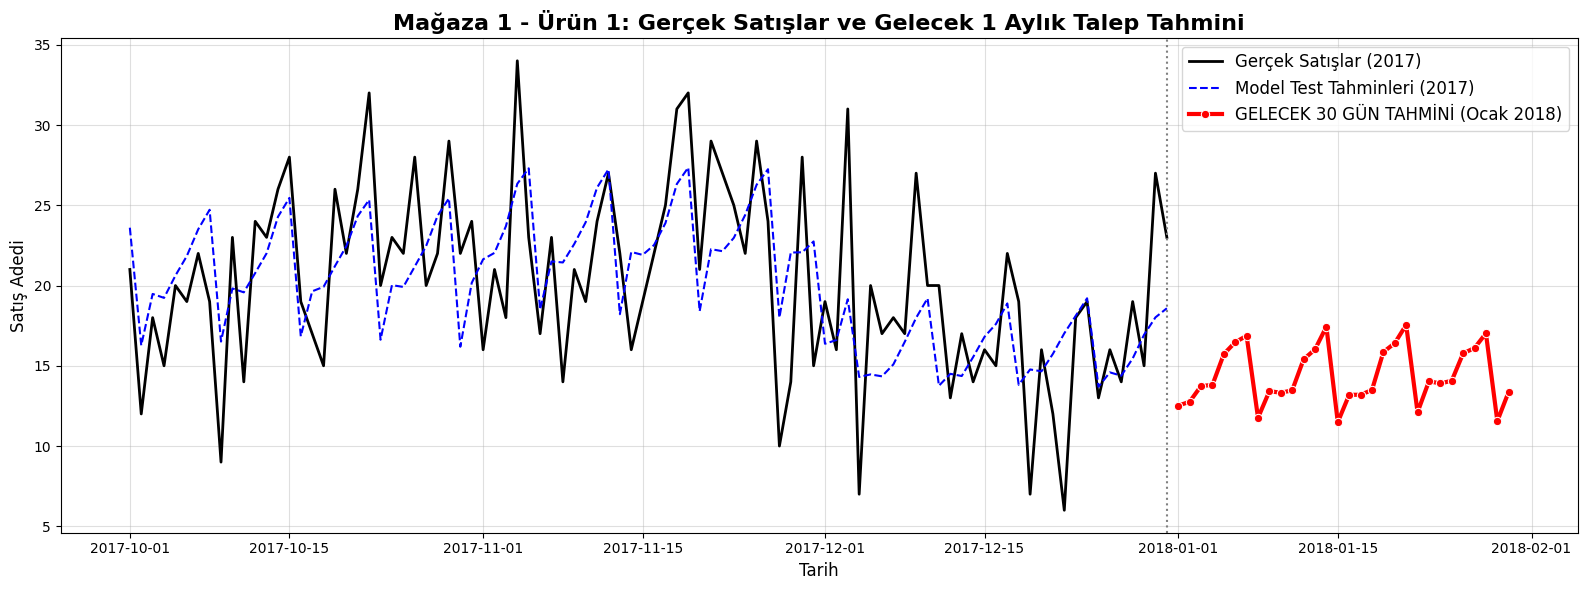

In [ ]:
                                                   # GELECEK 1 AYLIK TAHMİN VE GÖRSELLEŞTİRME



# 2017'nin son 3 ayındaki (Ekim-Kasım-Aralık) GERÇEK ve TAHMİN edilen satışları alalım:

ornek_test = test[(test['store'] == 1) & (test['item'] == 1) & (test['date'] >= '2017-10-01')].copy()
ornek_test['predicted_sales'] = model.predict(ornek_test[features])

# 1. Gelecek 30 Günün Takvimini Oluşturma (1 Ocak 2018 - 30 Ocak 2018)

gelecek_tarihler = pd.date_range(start='2018-01-01', periods=30)
gelecek_df = pd.DataFrame({'date': gelecek_tarihler, 'store': 1, 'item': 1})

# Özellik Mühendisliğini gelecek 30 gün için tekrarlama

gelecek_df['year'] = gelecek_df['date'].dt.year
gelecek_df['month'] = gelecek_df['date'].dt.month
gelecek_df['day'] = gelecek_df['date'].dt.day
gelecek_df['dayofweek'] = gelecek_df['date'].dt.dayofweek
gelecek_df['is_weekend'] = (gelecek_df['date'].dt.dayofweek >= 5).astype(int)

#  Modeli Kullanarak Gelecek 30 Günün Tahminini Yapma
gelecek_df['predicted_sales'] = model.predict(gelecek_df[features])

#  Görselleştirme (Gerçek Satışlar + Modelin 2017 Tahmini + 2018 Gelecek Tahmini)
plt.figure(figsize=(16, 6))

# Gerçekleşen Satışlar (Siyah Düz Çizgi)
sns.lineplot(data=ornek_test, x='date', y='sales', label='Gerçek Satışlar (2017)', color='black', linewidth=2)

# Modelimizin 2017 Test Tahminleri (Mavi Kesik Çizgi)
sns.lineplot(data=ornek_test, x='date', y='predicted_sales', label='Model Test Tahminleri (2017)', color='blue', linestyle='--')

# Modelimizin 2018 GELECEK Tahminleri (Kırmızı Kalın Çizgi)
sns.lineplot(data=gelecek_df, x='date', y='predicted_sales', label='GELECEK 30 GÜN TAHMİNİ (Ocak 2018)', color='red', linewidth=3, marker='o')

# Çizim Ayarları
plt.title("Mağaza 1 - Ürün 1: Gerçek Satışlar ve Gelecek 1 Aylık Talep Tahmini", fontsize=16, fontweight='bold')
plt.xlabel("Tarih", fontsize=12)
plt.ylabel("Satış Adedi", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.4)
plt.axvline(pd.to_datetime('2017-12-31'), color='gray', linestyle=':', label='2017 Sonu') # Yılı ayıran çizgi

plt.tight_layout()
plt.show()